In [12]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, make_scorer, f1_score,
    precision_score, recall_score, roc_curve
)
from scipy.sparse import csr_matrix
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#df = pd.read_parquet(r"MODEL_READY_MATRIX.parquet")
df = pd.read_parquet(r"MODEL_READY_MATRIX_BALANCED.parquet")

print(f"Loaded matrix: {df.shape}")
print(f"  Label=1 (Disease): {(df['LABEL']==1).sum()}")
print(f"  Label=0 (Control): {(df['LABEL']==0).sum()}")

feature_cols = [c for c in df.columns if c not in ['SUBJECT_ID', 'LABEL']]
X = df[feature_cols]
y = df['LABEL']
X = X.astype(np.float32)
X_sparse = csr_matrix(X.values)

print(f"Features: {X.shape[1]}")

#in

Loaded matrix: (152, 7806)
  Label=1 (Disease): 76
  Label=0 (Control): 76
Features: 7804


In [14]:
#CV Setup
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score, zero_division=0),
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'roc_auc': 'roc_auc',
}

In [15]:
# setup random forest classifier with hyperparameters that are reasonable for this dataset #this is first pass
# class_weight='balanced_subsample' reweights per bootstrap sample
# which is CRITICAL given the ~1:600 imbalance ratio
rf_base = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features='sqrt',        # decorrelate trees
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1,
)

print("\n[1/3] Training Random Forest (baseline) with cross-validation...")
rf_cv = cross_validate(
    rf_base, X_sparse, y,
    cv=skf,
    scoring=scoring,
    return_estimator=True,
    n_jobs=1  # outer loop sequential to avoid mem issues w/ nested parallelism
)

print("\nRandom Forest Baseline Results (mean ± std across folds):")
for metric in scoring:
    scores = rf_cv[f'test_{metric}']
    print(f"  {metric}: {scores.mean():.4f} ± {scores.std():.4f}")


[1/3] Training Random Forest (baseline) with cross-validation...

Random Forest Baseline Results (mean ± std across folds):
  accuracy: 0.7032 ± 0.1188
  f1: 0.7139 ± 0.1157
  precision: 0.6902 ± 0.1095
  recall: 0.7483 ± 0.1438
  roc_auc: 0.7922 ± 0.1204


In [16]:
print("\n[2/3] Running RandomizedSearchCV for hyperparameter tuning...")

param_dist = {
    'n_estimators': randint(300, 1000),
    'max_depth': randint(5, 25),
    'min_samples_leaf': randint(2, 20),
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', 0.1, 0.2, 0.3],
    'class_weight': ['balanced', 'balanced_subsample'],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=skf,
    random_state=42,
    n_jobs=1,
    verbose=1,
)
rf_search.fit(X_sparse, y)

print(f"\nBest AUC from search: {rf_search.best_score_:.4f}")
print(f"Best params: {rf_search.best_params_}")


[2/3] Running RandomizedSearchCV for hyperparameter tuning...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best AUC from search: 0.7981
Best params: {'class_weight': 'balanced', 'max_depth': 11, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 13, 'n_estimators': 947}


In [17]:
print("\n[3/3] Evaluating tuned Random Forest with cross-validation...")
rf_tuned = rf_search.best_estimator_

rf_tuned_cv = cross_validate(
    rf_tuned, X_sparse, y,
    cv=skf,
    scoring=scoring,
    return_estimator=True,
    n_jobs=1
)

print("\nTuned Random Forest Results (mean ± std across folds):")
for metric in scoring:
    scores = rf_tuned_cv[f'test_{metric}']
    print(f"  {metric}: {scores.mean():.4f} ± {scores.std():.4f}")


[3/3] Evaluating tuned Random Forest with cross-validation...

Tuned Random Forest Results (mean ± std across folds):
  accuracy: 0.7428 ± 0.1115
  f1: 0.7519 ± 0.1106
  precision: 0.7231 ± 0.1015
  recall: 0.8000 ± 0.1687
  roc_auc: 0.7981 ± 0.1104


In [18]:
rf_tuned_importances = np.mean(
    [est.feature_importances_ for est in rf_tuned_cv['estimator']],
    axis=0
)
rf_tuned_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_tuned_importances
}).sort_values('importance', ascending=False)

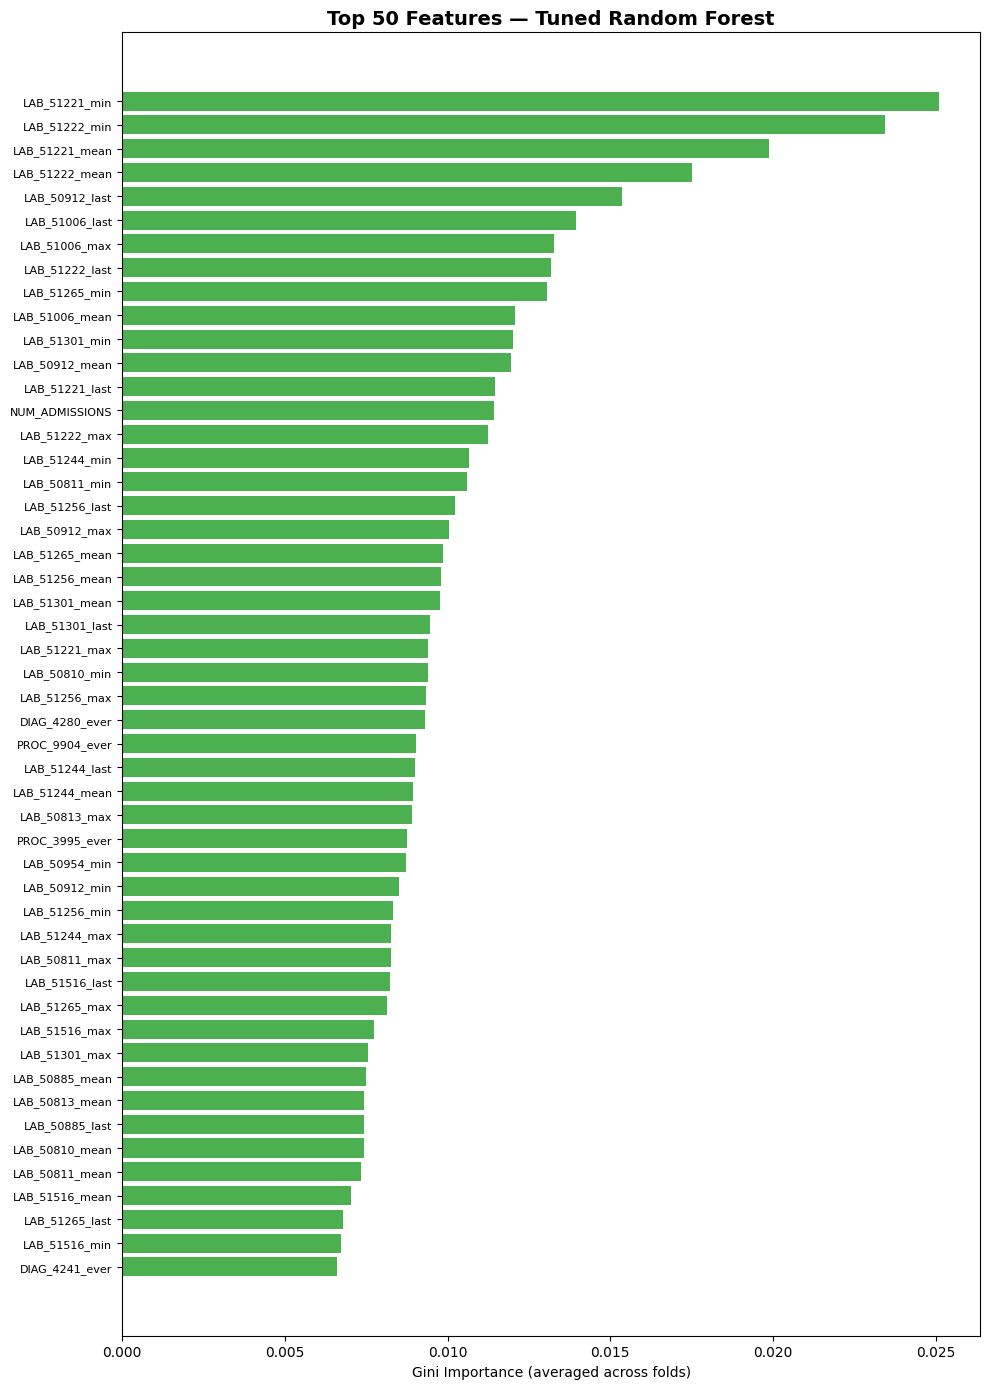

Saved: RF_Tuned_Top50_Features.png


In [19]:
TOP_N = 50

# 8a. Feature importance bar chart
rf_top = rf_tuned_importance_df.head(TOP_N).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(rf_top['feature'], rf_top['importance'], color='#4CAF50')
ax.set_xlabel('Gini Importance (averaged across folds)')
ax.set_title(f'Top {TOP_N} Features — Tuned Random Forest', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(r"RF_Tuned_Top50_Features.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: RF_Tuned_Top50_Features.png")

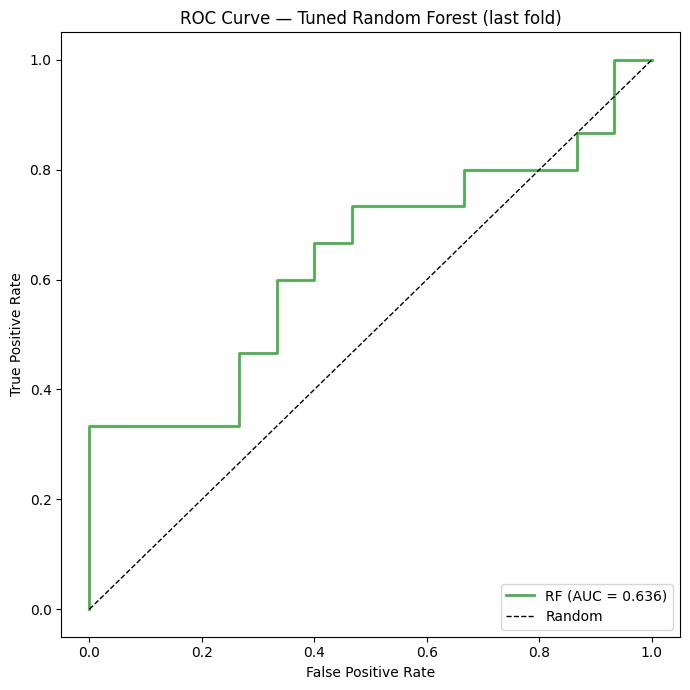

Saved: RF_Tuned_ROC.png


In [20]:
fold_indices = list(skf.split(X_sparse, y))
_, test_idx = fold_indices[-1]
X_test_fold = X_sparse[test_idx]
y_test_fold = y.iloc[test_idx]

rf_last = rf_tuned_cv['estimator'][-1]
y_prob = rf_last.predict_proba(X_test_fold)[:, 1]
fpr, tpr, _ = roc_curve(y_test_fold, y_prob)
auc_val = roc_auc_score(y_test_fold, y_prob)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(fpr, tpr, color='#4CAF50', lw=2, label=f'RF (AUC = {auc_val:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Tuned Random Forest (last fold)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(r"RF_Tuned_ROC.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: RF_Tuned_ROC.png")

In [21]:
y_pred = rf_last.predict(X_test_fold)
print("\n" + "=" * 60)
print("Tuned Random Forest — Classification Report (last fold)")
print("=" * 60)
print(classification_report(y_test_fold, y_pred, target_names=['Control', 'Disease']))

# 8d. Confusion matrix (last fold)
cm = confusion_matrix(y_test_fold, y_pred)
print("Confusion Matrix:")
print(cm)


Tuned Random Forest — Classification Report (last fold)
              precision    recall  f1-score   support

     Control       0.62      0.67      0.65        15
     Disease       0.64      0.60      0.62        15

    accuracy                           0.63        30
   macro avg       0.63      0.63      0.63        30
weighted avg       0.63      0.63      0.63        30

Confusion Matrix:
[[10  5]
 [ 6  9]]


In [22]:
rf_tuned_importance_df.to_csv(
    r"RF_Tuned_Feature_Importances.csv", index=False
)
print("\nSaved feature importance CSV.")


Saved feature importance CSV.
